# Layer 3 — HDBSCAN Clustering & Hotspot Detection
Bengaluru Traffic Intelligence Platform (BTIP) | Flipkart Gridlock 2.0

In [1]:
import sys
sys.path.insert(0, '..')   # repo root

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pyproj import Transformer

plt.style.use('dark_background')
CYAN = '#00D4FF'
AMBER = '#FFB020'
RED = '#FF4444'
GREEN = '#00A86B'

## 1. Load Feature Store

In [2]:
df = pl.read_parquet('../data/processed/feature_store.parquet')
print(f'Rows: {len(df):,} | Columns: {len(df.columns)}')
print(df.head(3))

Rows: 298,282 | Columns: 43
shape: (3, 43)
┌────────────┬───────────┬───────────┬────────────┬───┬────────────┬───────────┬───────────┬───────┐
│ id         ┆ latitude  ┆ longitude ┆ location   ┆ … ┆ rolling_30 ┆ offence_t ┆ road_type ┆ lanes │
│ ---        ┆ ---       ┆ ---       ┆ ---        ┆   ┆ d_count    ┆ ime_cross ┆ ---       ┆ ---   │
│ str        ┆ f64       ┆ f64       ┆ str        ┆   ┆ ---        ┆ ---       ┆ str       ┆ i64   │
│            ┆           ┆           ┆            ┆   ┆ u32        ┆ str       ┆           ┆       │
╞════════════╪═══════════╪═══════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════╡
│ FKID113868 ┆ 13.184417 ┆ 77.679714 ┆ Unnamed    ┆ … ┆ null       ┆ NO PARKIN ┆ null      ┆ null  │
│            ┆           ┆           ┆ Road,      ┆   ┆            ┆ G_Morning ┆           ┆       │
│            ┆           ┆           ┆ Begur Chik ┆   ┆            ┆           ┆           ┆       │
│            ┆           ┆           ┆ kanaha…  

## 2. UTM Projection & Coordinate Scatter

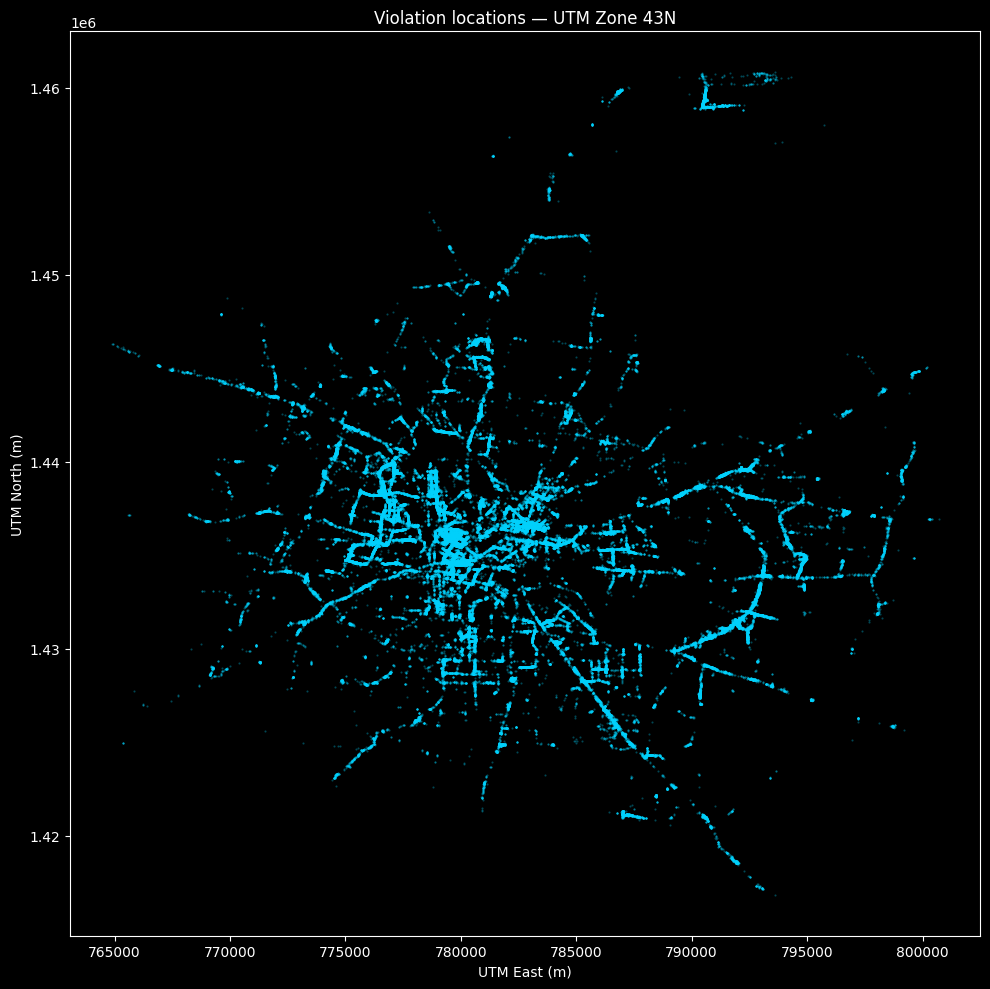

In [3]:
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32643', always_xy=True)

df_valid = df.filter(
    pl.col('latitude').is_between(12.8, 13.2) &
    pl.col('longitude').is_between(77.4, 77.8)
)

lat = df_valid['latitude'].to_numpy()
lon = df_valid['longitude'].to_numpy()
utm_x, utm_y = transformer.transform(lon, lat)

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(utm_x, utm_y, s=0.3, alpha=0.3, c=CYAN)
ax.set_title('Violation locations — UTM Zone 43N', color='white')
ax.set_xlabel('UTM East (m)')
ax.set_ylabel('UTM North (m)')
plt.tight_layout()
plt.show()

## 3. Run HDBSCAN & Visualise Clusters

In [4]:
from backend.models.clustering.hdbscan_model import train, load_feature_store, cluster_summary

# If already trained, load; else train
from pathlib import Path
MODEL_PATH = Path('../models/saved/clustering/hdbscan_model.joblib')

if MODEL_PATH.exists():
    import joblib, hdbscan as hdbscan_lib
    model = joblib.load(MODEL_PATH)
    df_cl = pl.read_parquet('../data/processed/clustered_feature_store.parquet')
    print('Loaded existing model & clustered store.')
else:
    model, df_cl = train(df=df_valid)

labels = df_cl['cluster_id'].to_numpy()
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pct = 100 * (labels == -1).sum() / len(labels)
print(f'Clusters: {n_clusters}  |  Noise: {noise_pct:.1f}%')

Loaded existing model & clustered store.
Clusters: 1191  |  Noise: 20.3%


C:\Users\Acer\AppData\Local\Temp\ipykernel_26980\4198678059.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_clusters)


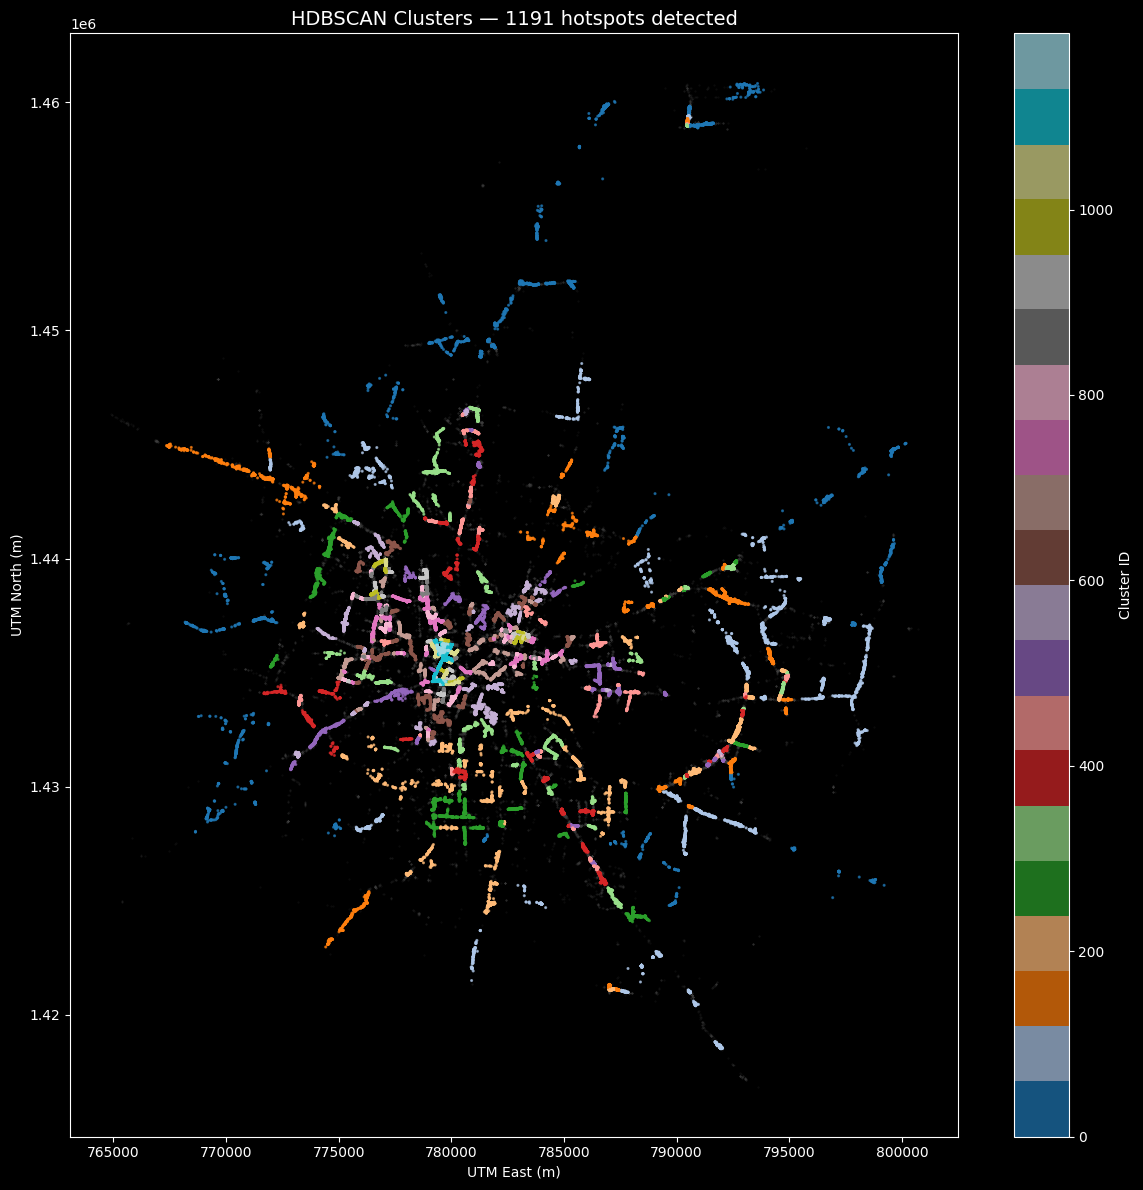

In [5]:
# Visualise clusters
lat_arr = df_cl['latitude'].to_numpy()
lon_arr = df_cl['longitude'].to_numpy()
utm_x2, utm_y2 = transformer.transform(lon_arr, lat_arr)

fig, ax = plt.subplots(figsize=(12, 12))

# Noise in grey
noise_mask = labels == -1
ax.scatter(utm_x2[noise_mask], utm_y2[noise_mask], s=0.2, c='#444', alpha=0.2, label='Noise')

# Clusters in colour
cluster_mask = ~noise_mask
cmap = plt.cm.get_cmap('tab20', n_clusters)
sc = ax.scatter(
    utm_x2[cluster_mask], utm_y2[cluster_mask],
    s=1.5, c=labels[cluster_mask], cmap=cmap, alpha=0.7
)
plt.colorbar(sc, ax=ax, label='Cluster ID')
ax.set_title(f'HDBSCAN Clusters — {n_clusters} hotspots detected', color='white', fontsize=14)
ax.set_xlabel('UTM East (m)')
ax.set_ylabel('UTM North (m)')
plt.tight_layout()
plt.show()

## 4. Cluster Summary Table

In [6]:
summary = cluster_summary(df_cl)
print(summary.head(20))

shape: (20, 5)
┌────────────┬──────────────┬──────────────┬─────────────────┬──────────────────────────┐
│ cluster_id ┆ centroid_lat ┆ centroid_lng ┆ violation_count ┆ mean_cluster_probability │
│ ---        ┆ ---          ┆ ---          ┆ ---             ┆ ---                      │
│ i64        ┆ f64          ┆ f64          ┆ u32             ┆ f64                      │
╞════════════╪══════════════╪══════════════╪═════════════════╪══════════════════════════╡
│ 340        ┆ 13.008262    ┆ 77.695197    ┆ 3339            ┆ 0.982872                 │
│ 990        ┆ 12.981443    ┆ 77.608695    ┆ 2695            ┆ 0.982342                 │
│ 550        ┆ 13.071329    ┆ 77.58813     ┆ 2693            ┆ 0.972511                 │
│ 840        ┆ 12.984071    ┆ 77.603529    ┆ 2667            ┆ 0.875093                 │
│ 1047       ┆ 12.981052    ┆ 77.610193    ┆ 2431            ┆ 0.957252                 │
│ …          ┆ …            ┆ …            ┆ …               ┆ …                     

## 5. Persistence Score Distribution

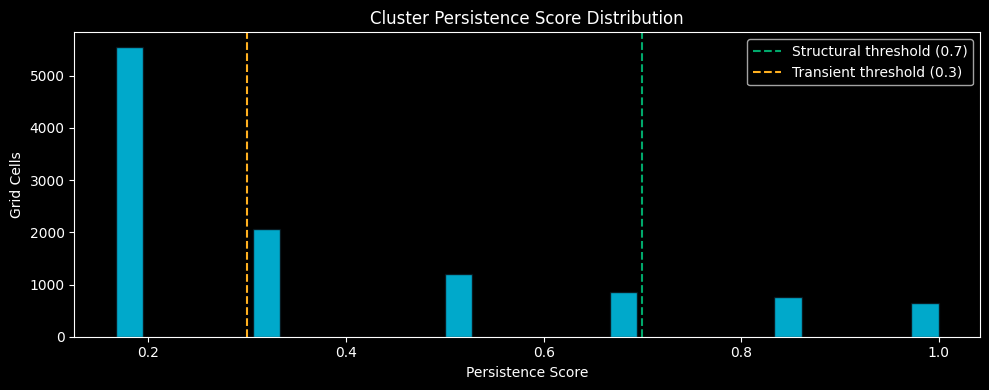

Structural (>0.7): 1,407
Moderate (0.3-0.7): 4,129
Transient (<0.3): 5,555


In [7]:
from pathlib import Path
persist_path = Path('../data/processed/cluster_persistence.parquet')

if persist_path.exists():
    persist_df = pl.read_parquet(persist_path)
    scores = persist_df['persistence_score'].to_numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(scores, bins=30, color=CYAN, edgecolor='#0B0E14', alpha=0.8)
    ax.axvline(0.7, color=GREEN, linestyle='--', label='Structural threshold (0.7)')
    ax.axvline(0.3, color=AMBER, linestyle='--', label='Transient threshold (0.3)')
    ax.set_xlabel('Persistence Score')
    ax.set_ylabel('Grid Cells')
    ax.set_title('Cluster Persistence Score Distribution', color='white')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Structural (>0.7): {(scores > 0.7).sum():,}")
    print(f"Moderate (0.3-0.7): {((scores >= 0.3) & (scores <= 0.7)).sum():,}")
    print(f"Transient (<0.3): {(scores < 0.3).sum():,}")
else:
    print('Run scripts/train_clustering.py first to generate persistence scores.')

## 6. Hour × Day Heatmap for Top Cluster

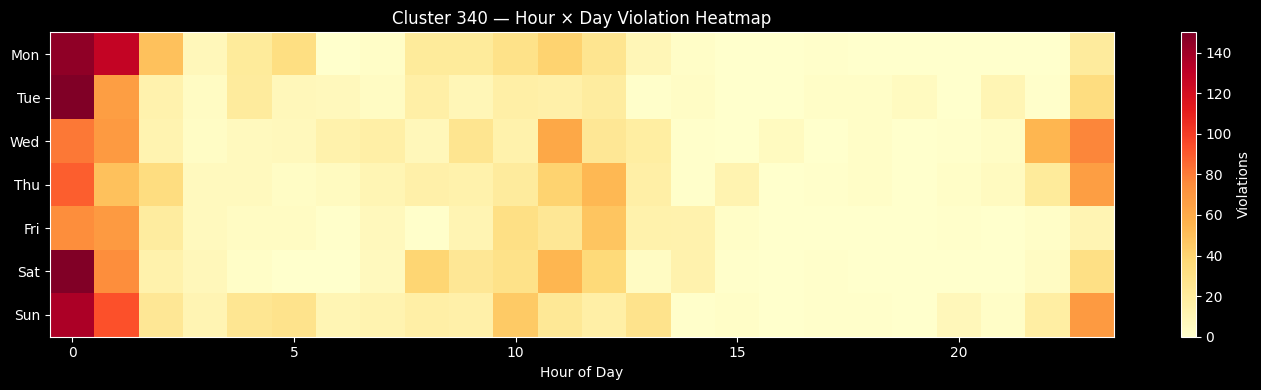

In [8]:
# Pick top cluster by violation count
top_cluster = summary['cluster_id'][0]
cluster_df = df_cl.filter(pl.col('cluster_id') == top_cluster)

if 'hour' in cluster_df.columns and 'day_of_week' in cluster_df.columns:
    grid = cluster_df.group_by(['day_of_week', 'hour']).agg(pl.count('id').alias('count'))
    grid_pd = grid.to_pandas().pivot(index='day_of_week', columns='hour', values='count').fillna(0)

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(grid_pd.values, aspect='auto', cmap='YlOrRd')
    ax.set_yticks(range(7))
    ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
    ax.set_xlabel('Hour of Day')
    ax.set_title(f'Cluster {top_cluster} — Hour × Day Violation Heatmap', color='white')
    plt.colorbar(im, ax=ax, label='Violations')
    plt.tight_layout()
    plt.show()
else:
    print('hour/day_of_week columns not found — check Layer 2 feature engineering.')